In [45]:
from coffea.util import load
import awkward as ak
import numpy as np
from collections import Counter

In [46]:
ggf_signal = load("/work/tharte/datasets/samples_vbf_boosted/vbf_ggf/1_16_3_fixed_workflow/output_GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE.coffea")
vbf_signal = load("/work/tharte/datasets/samples_vbf_boosted/vbf_ggf/1_16_3_fixed_workflow/output_VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE.coffea")
# data_e = load("/work/tharte/datasets/samples_vbf_boosted/vbf_ggf/1_16_3_fixed_workflow/output_DATA_JetMET_JMENano_E_2022_postEE_EraE.coffea")
# data_f = load("/work/tharte/datasets/samples_vbf_boosted/vbf_ggf/1_16_3_fixed_workflow/output_DATA_JetMET_JMENano_F_2022_postEE_EraF.coffea")
# vbf_signal_after_restructure = load("/work/tharte/datasets/samples_vbf_boosted/1_16_2_ggf_vs_vbf/1_16_2_vbf_with_discriminator_new_ordering/output_VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE.coffea")
vbf_signal_ar_debug = load("/work/tharte/datasets/samples_vbf_boosted/vbf_ggf/1_16_3_fixed_workflow/output_VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE.coffea")
# ggf_signal_after_restructure = load("/work/tharte/datasets/samples_vbf_boosted/1_16_2_ggf_vs_vbf/1_16_2_vbf_with_discriminator_new_ordering/output_GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE.coffea")

In [47]:
ggf_signal_ggf = ggf_signal["columns"]['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed']['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE']['boosted_vbf_fail_region']["nominal"]
ggf_signal_vbf = ggf_signal["columns"]['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed']['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE']['boosted_vbf_pass_region']["nominal"]

In [48]:
ggf_signal_ggf_ar = ggf_signal_after_restructure["columns"]['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed']['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE']['boosted_vbf_fail_region']["nominal"]
ggf_signal_vbf_ar = ggf_signal_after_restructure["columns"]['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed']['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE']['boosted_vbf_pass_region']["nominal"]

NameError: name 'ggf_signal_after_restructure' is not defined

In [49]:
vbf_signal_ggf = vbf_signal["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_fail_region']["nominal"]
vbf_signal_vbf = vbf_signal["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_pass_region']["nominal"]
vbf_signal_all = vbf_signal["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']
print(vbf_signal_all.keys())
print(len(vbf_signal_all["boosted_vbf_signal_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_vbf_ttbar_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_vbf_qcd_A_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_vbf_qcd_B_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_vbf_qcd_C_region"]["nominal"]["weight"].value))

dict_keys(['boosted_vbf_signal_region', 'boosted_vbf_ttbar_region', 'boosted_vbf_pass_region', 'boosted_vbf_fail_region', 'boosted_vbf_qcd_A_region', 'boosted_vbf_qcd_B_region', 'boosted_vbf_qcd_C_region'])
1025


In [50]:
vbf_signal_ggf_ar = vbf_signal_after_restructure["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_fail_region']["nominal"]
vbf_signal_vbf_ar = vbf_signal_after_restructure["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_pass_region']["nominal"]
vbf_signal_all_ar = vbf_signal_after_restructure["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']
print(vbf_signal_all_ar.keys())
print(len(vbf_signal_all_ar["boosted_vbf_signal_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_ttbar_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_qcd_A_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_qcd_B_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_qcd_C_region"]["nominal"]["weight"].value))

NameError: name 'vbf_signal_after_restructure' is not defined

In [51]:
vbf_signal_ggf_ar_debug = vbf_signal_ar_debug["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_fail_region']["nominal"]
vbf_signal_vbf_ar_debug = vbf_signal_ar_debug["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_pass_region']["nominal"]
vbf_signal_all_ar_debug = vbf_signal_ar_debug["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']

In [52]:
data_ggf = data_e["columns"]['DATA_JetMET_JMENano_E_skimmed']['DATA_JetMET_JMENano_E_2022_postEE_EraE']['boosted_vbf_fail_region']["nominal"]
data_vbf = data_e["columns"]['DATA_JetMET_JMENano_E_skimmed']['DATA_JetMET_JMENano_E_2022_postEE_EraE']['boosted_vbf_pass_region']["nominal"]

KeyError: 'DATA_JetMET_JMENano_E_skimmed'

In [53]:
data_f_ggf = data_f["columns"]['DATA_JetMET_JMENano_F_skimmed']['DATA_JetMET_JMENano_F_2022_postEE_EraF']['boosted_vbf_fail_region']["nominal"]
data_f_vbf = data_f["columns"]['DATA_JetMET_JMENano_F_skimmed']['DATA_JetMET_JMENano_F_2022_postEE_EraF']['boosted_vbf_pass_region']["nominal"]

KeyError: 'DATA_JetMET_JMENano_F_skimmed'

In [54]:
print("Looking at ggF signal")
print(f"ggF classified sum: {sum(ggf_signal_ggf['weight'].value)}")
print(f"VBF classified sum: {sum(ggf_signal_vbf['weight'].value)}")
print(f"ggF classified len: {len(ggf_signal_ggf['weight'].value)}")
print(f"VBF classified len: {len(ggf_signal_vbf['weight'].value)}")

Looking at ggF signal
ggF classified sum: 69303.58541001755
VBF classified sum: 494.8177152226777
ggF classified len: 8440
VBF classified len: 58


In [55]:
print("Looking at ggF signal")
print(f"ggF classified sum: {sum(ggf_signal_ggf_ar['weight'].value)}")
print(f"VBF classified sum: {sum(ggf_signal_vbf_ar['weight'].value)}")
print(f"ggF classified len: {len(ggf_signal_ggf_ar['weight'].value)}")
print(f"VBF classified len: {len(ggf_signal_vbf_ar['weight'].value)}")

Looking at ggF signal


NameError: name 'ggf_signal_ggf_ar' is not defined

In [56]:
print("Looking at VBF signal")
print(f"ggF classified sum: {sum(vbf_signal_ggf['weight'].value)}")
print(f"VBF classified sum: {sum(vbf_signal_vbf['weight'].value)}")
print(f"ggF classified len: {len(vbf_signal_ggf['weight'].value)}")
print(f"VBF classified len: {len(vbf_signal_vbf['weight'].value)}")
print(Counter(vbf_signal_ggf["JetGoodVBF_N"].value))
# print(Counter(vbf_signal_ggf["DiJetVBFCandidates_pt"].value))

Looking at VBF signal
ggF classified sum: 80524.79618700808
VBF classified sum: 18566.863834199776
ggF classified len: 4710
VBF classified len: 1086
Counter({2: 4710})


In [57]:
print("Looking at VBF signal")
print(f"ggF classified sum: {sum(vbf_signal_ggf_ar['weight'].value)}")
print(f"VBF classified sum: {sum(vbf_signal_vbf_ar['weight'].value)}")
print(f"ggF classified len: {len(vbf_signal_ggf_ar['weight'].value)}")
print(f"VBF classified len: {len(vbf_signal_vbf_ar['weight'].value)}")

Looking at VBF signal


NameError: name 'vbf_signal_ggf_ar' is not defined

In [58]:
print("Looking at VBF signal")
print(f"ggF classified sum: {sum(vbf_signal_ggf_ar_debug['weight'].value)}")
print(f"VBF classified sum: {sum(vbf_signal_vbf_ar_debug['weight'].value)}")
print(f"ggF classified len: {len(vbf_signal_ggf_ar_debug['weight'].value)}")
print(f"VBF classified len: {len(vbf_signal_vbf_ar_debug['weight'].value)}")
print(Counter(vbf_signal_ggf_ar_debug["LeadingVBFJet_phi"].value[vbf_signal_ggf_ar_debug["LeadingVBFJet_phi"].value>6]))
print(Counter(vbf_signal_ggf_ar_debug["JetGoodVBF_N"].value))
# print(Counter(vbf_signal_ggf_ar_debug["DiJetVBF_N"].value))

Looking at VBF signal
ggF classified sum: 80524.79618700808
VBF classified sum: 18566.863834199776
ggF classified len: 4710
VBF classified len: 1086
Counter()
Counter({2: 4710})


In [59]:
print("Looking at data")
print(f"ggF classified: {sum(data_ggf['weight'].value)}")
print(f"VBF classified: {sum(data_vbf['weight'].value)}")

Looking at data


NameError: name 'data_ggf' is not defined

In [60]:
print("Looking at data f")
print(f"ggF classified: {sum(data_f_ggf['weight'].value)}")
print(f"VBF classified: {sum(data_f_vbf['weight'].value)}")

Looking at data f


NameError: name 'data_f_ggf' is not defined

In [61]:
vbf_signal_vbf.keys()

dict_keys(['weight', 'JetGoodVBFCandidates_N', 'JetGoodVBFCandidates_phi', 'JetGoodVBFCandidates_eta', 'JetGoodVBFCandidates_provenance', 'JetGoodVBFCandidates_pt', 'JetGoodVBFCandidates_mass', 'events_dEta', 'events_year', 'events_era', 'events_HT', 'HiggsLeading_phi', 'HiggsLeading_eta', 'HiggsLeading_m_Hjet_min_dR', 'HiggsLeading_pt', 'HiggsLeading_dR_Hjet_min', 'HiggsLeading_btagBB_3wp', 'HiggsLeading_mass_regr', 'HiggsLeading_centrality', 'HiggsSubLeading_phi', 'HiggsSubLeading_eta', 'HiggsSubLeading_m_Hjet_min_dR', 'HiggsSubLeading_pt', 'HiggsSubLeading_dR_Hjet_min', 'HiggsSubLeading_btagBB_3wp', 'HiggsSubLeading_mass_regr', 'HiggsSubLeading_centrality', 'HH_phi', 'HH_eta', 'HH_dPhi', 'HH_dR', 'HH_pt', 'HH_mass', 'HH_dEta', 'HH_Costhetastar_CS', 'LeadingVBFJet_phi', 'LeadingVBFJet_pt', 'LeadingVBFJet_eta', 'LeadingVBFJet_mass', 'SubLeadingVBFJet_phi', 'SubLeadingVBFJet_pt', 'SubLeadingVBFJet_eta', 'SubLeadingVBFJet_mass', 'MET_sumEt', 'JetGoodVBF_N', 'JetGoodVBF_provenance', 'eve

In [62]:
print(vbf_signal_vbf_ar_debug["HiggsLeading_eta"])
print(vbf_signal_vbf_ar_debug["HiggsSubLeading_eta"])

column_accumulator(array([-0.11846924, -0.98413086,  2.1269531 , ...,  0.56677246,
       -2.3081055 , -2.0605469 ], dtype=float32))
column_accumulator(array([ 1.4477539 ,  1.6743164 , -0.24234009, ...,  0.48809814,
        0.861084  , -0.9691162 ], dtype=float32))


In [63]:
print(max(abs(vbf_signal_vbf_ar_debug["HiggsLeading_eta"].value[abs(vbf_signal_vbf_ar_debug["HiggsLeading_eta"].value)<998])))
print(max(abs(vbf_signal_vbf_ar_debug["HiggsSubLeading_eta"].value)))

2.399414
2.3969727


In [64]:
print(max(abs(vbf_signal_vbf_ar["LeadingVBFJet_eta"].value)))
print(max(abs(vbf_signal_vbf_ar["SubLeadingVBFJet_eta"].value)))
print(min(abs(vbf_signal_vbf_ar["LeadingVBFJet_eta"].value)))
print(min(abs(vbf_signal_vbf_ar["SubLeadingVBFJet_eta"].value)))

NameError: name 'vbf_signal_vbf_ar' is not defined

In [65]:
print(max(abs(vbf_signal_vbf_ar["LeadingVBFJet_eta"].value)))
print(max(abs(vbf_signal_vbf_ar["SubLeadingVBFJet_eta"].value)))
print(min(abs(vbf_signal_vbf_ar["LeadingVBFJet_eta"].value)))
print(min(abs(vbf_signal_vbf_ar["SubLeadingVBFJet_eta"].value)))

NameError: name 'vbf_signal_vbf_ar' is not defined

# Boosted with new cuts Preparation for reweighting
I now changed the cuts to see, if we get a larger amount of events.
Changes performed:
- msd: 50 -> 40
- mass_regr_min: 50 -> 40
- mjj min: 400 -> 300
- subleading bbtag min: 0.05 -> 0.00

In [66]:
data_e = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_3_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06/output_DATA_JetMET_JMENano_E_2022_postEE_EraE.coffea")
data_f = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_3_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06/output_DATA_JetMET_JMENano_F_2022_postEE_EraF.coffea")
data_g = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_3_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06/output_DATA_JetMET_JMENano_G_2022_postEE_EraG.coffea")

In [67]:
eraE_regionA = data_e["columns"]['DATA_JetMET_JMENano_E']['DATA_JetMET_JMENano_E_2022_postEE_EraE']['boosted_vbf_incl_qcd_A_region']["nominal"]
eraE_regionB = data_e["columns"]['DATA_JetMET_JMENano_E']['DATA_JetMET_JMENano_E_2022_postEE_EraE']['boosted_vbf_incl_qcd_B_region']["nominal"]
eraF_regionA = data_f["columns"]['DATA_JetMET_JMENano_F']['DATA_JetMET_JMENano_F_2022_postEE_EraF']['boosted_vbf_incl_qcd_A_region']["nominal"]
eraF_regionB = data_f["columns"]['DATA_JetMET_JMENano_F']['DATA_JetMET_JMENano_F_2022_postEE_EraF']['boosted_vbf_incl_qcd_B_region']["nominal"]
eraG_regionA = data_g["columns"]['DATA_JetMET_JMENano_G']['DATA_JetMET_JMENano_G_2022_postEE_EraG']['boosted_vbf_incl_qcd_A_region']["nominal"]
eraG_regionB = data_g["columns"]['DATA_JetMET_JMENano_G']['DATA_JetMET_JMENano_G_2022_postEE_EraG']['boosted_vbf_incl_qcd_B_region']["nominal"]

In [68]:
eraE_regionA.keys()

dict_keys(['weight', 'events_event', 'JetGoodVBF_N', 'JetGoodVBF_eta', 'JetGoodVBF_mass', 'JetGoodVBF_provenance', 'JetGoodVBF_phi', 'JetGoodVBF_pt', 'events_dEta', 'events_era', 'events_year', 'events_HT', 'HiggsLeading_eta', 'HiggsLeading_btagBB', 'HiggsLeading_phi', 'HiggsLeading_m_Hjet_min_dR', 'HiggsLeading_mass_regr', 'HiggsLeading_btagBB_3wp', 'HiggsLeading_dR_Hjet_min', 'HiggsLeading_pt', 'HiggsLeading_centrality', 'HiggsSubLeading_eta', 'HiggsSubLeading_btagBB', 'HiggsSubLeading_phi', 'HiggsSubLeading_m_Hjet_min_dR', 'HiggsSubLeading_mass_regr', 'HiggsSubLeading_btagBB_3wp', 'HiggsSubLeading_dR_Hjet_min', 'HiggsSubLeading_pt', 'HiggsSubLeading_centrality', 'HH_eta', 'HH_mass', 'HH_dR', 'HH_dPhi', 'HH_phi', 'HH_dEta', 'HH_pt', 'HH_Costhetastar_CS', 'LeadingVBFJet_eta', 'LeadingVBFJet_pt', 'LeadingVBFJet_phi', 'LeadingVBFJet_mass', 'SubLeadingVBFJet_eta', 'SubLeadingVBFJet_pt', 'SubLeadingVBFJet_phi', 'SubLeadingVBFJet_mass', 'MET_sumEt', 'JetGoodVBFCandidates_N', 'JetGoodVBFCan

In [69]:
bbtags = np.concatenate([eraE_regionA['HiggsSubLeading_btagBB'].value, eraE_regionB['HiggsSubLeading_btagBB'].value, eraF_regionA['HiggsSubLeading_btagBB'].value, eraF_regionB['HiggsSubLeading_btagBB'].value, eraG_regionA['HiggsSubLeading_btagBB'].value, eraG_regionB['HiggsSubLeading_btagBB'].value])

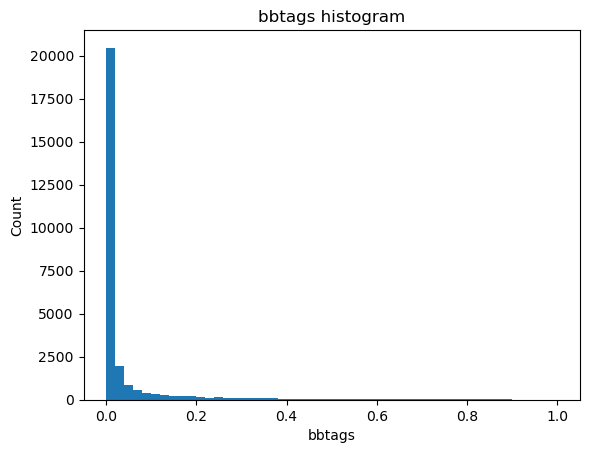

In [77]:
import matplotlib.pyplot as plt

plt.hist(bbtags, bins=50, range=(0, 1))
plt.xlabel('bbtags')
plt.ylabel('Count')
plt.title('bbtags histogram')
plt.show()

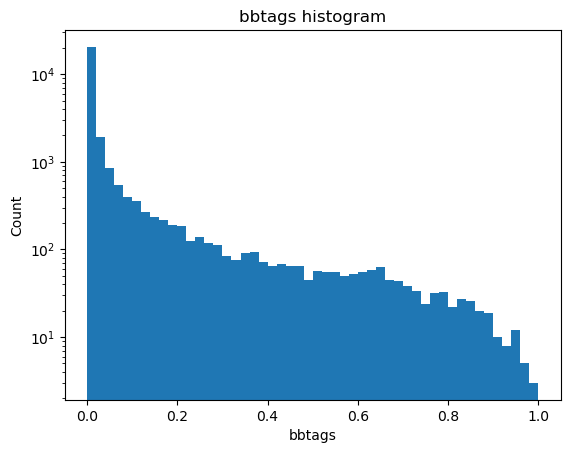

In [78]:
plt.hist(bbtags, bins=50, range=(0, 1))
plt.xlabel('bbtags')
plt.ylabel('Count')
plt.title('bbtags histogram')
plt.yscale("log")
plt.show()

In [74]:
bbtag_A = np.concatenate([eraE_regionA['HiggsSubLeading_btagBB'].value, eraF_regionA['HiggsSubLeading_btagBB'].value, eraG_regionA['HiggsSubLeading_btagBB'].value])
bbtag_B = np.concatenate([eraE_regionB['HiggsSubLeading_btagBB'].value, eraF_regionB['HiggsSubLeading_btagBB'].value, eraG_regionB['HiggsSubLeading_btagBB'].value])

In [76]:
print(len(bbtag_A))
print(len(bbtag_B))

27134
580
